**Insight: Overtime → Attrition**<br>
Model: K-Nearest Neighbors<br>
Target: Attrition<br>
Goal: Predict attrition using full dataset features

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Cleaned Dataset
df = pd.read_csv("cleaned_employee_data.csv")

In [5]:
# Define Features and Target
X = df.drop(columns=['Attrition'])
y = df['Attrition']

In [6]:
# Scale Features (KNN is sensitive to scale!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Train-Test Split, stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
# Train KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can test other K values too
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [15]:
# Predict
y_pred_knn = knn_model.predict(X_test)
y_probs_knn = knn_model.predict_proba(X_test)[:, 1]

Accuracy: 84.58%
Precision: 61.54%
Recall: 11.27%
F1 Score: 19.05%



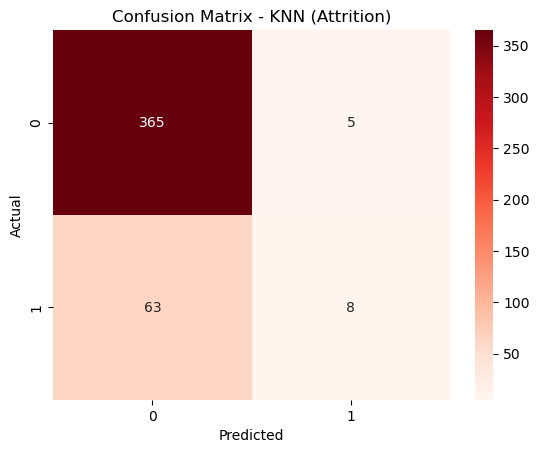

True Positives: 8
True Negatives: 365
False Positives: 5
False Negatives: 63


In [17]:
# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_knn)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_knn)*100:.2f}%")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - KNN (Attrition)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

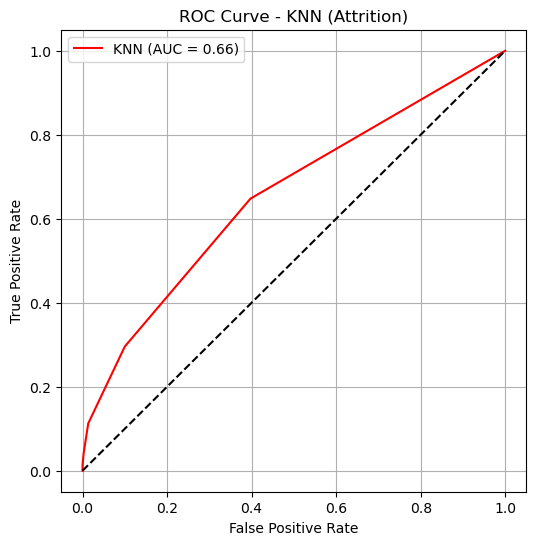

In [19]:
# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_probs_knn)
auc = roc_auc_score(y_test, y_probs_knn)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc:.2f})", color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - KNN (Attrition)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()